In [8]:
# --- 已废弃，请使用新版代码 ---
# ====== 第一步：重新加载音频，确保我们用的是“新鲜”数据 ======
import librosa
import numpy as np

# 注意：将 ‘your_file.mp3’ 换成你实际的MP3文件名
audio_path = './my_mp3_snores/snoring-1.mp3'  # <<< 这里要改！

# 加载音频
y, sr = librosa.load(audio_path, sr=None)
print(f"✅ 音频加载成功！")
print(f"   采样率: {sr} Hz, 总长度: {len(y)} 个点, 时长: {len(y)/sr:.2f} 秒")

# ====== 第二步：定义你的“知识” - 鼾声发生在哪些时间段 ======
# 将你在“第一步”中用笔记下的时间，填到下面这个列表里。
# 格式：每个括号里是一段鼾声的(开始时间, 结束时间)
my_snore_times = [
    (0.0, 1.6),    # 这是示例，改成你的第一个鼾声时间
    (2.5, 4.2),  # 改成你的第二个鼾声时间
    (5.2, 6.7)   # 改成你的第三个鼾声时间
]
print(f"🎯 我已记录 {len(my_snore_times)} 段鼾声。")
for start, end in my_snore_times:
    print(f"   - 从 {start} 秒 到 {end} 秒")

# ====== 第三步：定义“切片”和“打标签”的规则 ======
slice_duration = 0.5  # 每个切片0.5秒
slice_length = int(slice_duration * sr)  # 计算0.5秒对应多少个音频采样点
step = int(slice_length * 0.5)  # 滑动步长：每次前进半个切片（重叠50%）

def get_label_for_slice(slice_start_time, slice_end_time):
    """判断一个切片是否为鼾声：只要和已知鼾声时间段有重叠，就算鼾声。"""
    for snore_start, snore_end in my_snore_times:
        # 判断逻辑：切片结束时间 > 鼾声开始时间，且切片开始时间 < 鼾声结束时间
        if slice_end_time > snore_start and slice_start_time < snore_end:
            return 1  # 是鼾声
    return 0  # 不是鼾声

# 测试一下这个函数
test_label = get_label_for_slice(3.0, 3.5)  # 测试一个在鼾声范围内的切片
print(f"🧪 函数测试：时间片 3.0-3.5秒 的标签是 {test_label} (应为 1)")

# ====== 第四步：开始滑动切片，构建数据集 ======
X = []  # 用于存放所有特征
y_labels = []  # 用于存放所有标签（改名，避免和音频数据混淆）

# 【修复1】在重置 y 之前，先保存音频长度和数据
audio_length = len(y)  # 保存音频总长度（339840个点）
audio_data = y         # 保存音频数据，后面切片用

print("🔄 开始滑动切片处理音频...")

# 【修复2】用 audio_length 代替 len(y)
for start_sample in range(0, audio_length - slice_length, step):
    # 1. 切出一段音频（从 audio_data 取，不是从 y 取）
    end_sample = start_sample + slice_length
    audio_slice = audio_data[start_sample:end_sample]

    # 2. 计算这个切片的时间（秒）
    start_time = start_sample / sr
    end_time = end_sample / sr

    # 3. 获取这个切片的标签 (0 或 1)
    label = get_label_for_slice(start_time, end_time)

    # 4. 提取该切片的声音"指纹"（MFCC特征）
    mfccs = librosa.feature.mfcc(y=audio_slice, sr=sr, n_mfcc=13)
    mfccs_mean = mfccs.mean(axis=1)

    # 5. 保存到数据集
    X.append(mfccs_mean)
    y_labels.append(label)

# 将列表转换为NumPy数组
X = np.array(X)
y = np.array(y_labels)  # 转回 y，这样后面打印代码不用改

print("✅ 数据集构建完成！")
print(f"   特征数据 X 的形状: {X.shape} -> 表示有 {X.shape[0]} 个切片，每个切片有 {X.shape[1]} 个特征")
print(f"   标签数据 y 的形状: {y.shape}")
print(f"   其中，鼾声切片 (y=1) 有 {np.sum(y==1)} 个，非鼾声切片 (y=0) 有 {np.sum(y==0)} 个")

✅ 音频加载成功！
   采样率: 44100 Hz, 总长度: 339840 个点, 时长: 7.71 秒
🎯 我已记录 3 段鼾声。
   - 从 0.0 秒 到 1.6 秒
   - 从 2.5 秒 到 4.2 秒
   - 从 5.2 秒 到 6.7 秒
🧪 函数测试：时间片 3.0-3.5秒 的标签是 1 (应为 1)
🔄 开始滑动切片处理音频...
✅ 数据集构建完成！
   特征数据 X 的形状: (29, 13) -> 表示有 29 个切片，每个切片有 13 个特征
   标签数据 y 的形状: (29,)
   其中，鼾声切片 (y=1) 有 23 个，非鼾声切片 (y=0) 有 6 个


⚙️ 配置文件中...
配置了 5 个文件

实验1：5秒窗口（无重叠）
  🔍 处理: snoring-1.mp3
    标签统计: 正常3个, 严重0个
    ✅ 生成 1 个片段 (正常:1, 严重:0)
  🔍 处理: snoring-6.mp3
    标签统计: 正常12个, 严重0个
    ✅ 生成 6 个片段 (正常:6, 严重:0)
  🔍 处理: snoring-3.mp3
    标签统计: 正常3个, 严重0个
    ✅ 生成 1 个片段 (正常:1, 严重:0)
  🔍 处理: snoring-4.mp3
    标签统计: 正常6个, 严重0个
    ✅ 生成 6 个片段 (正常:6, 严重:0)
  🔍 处理: snoring-5.mp3
    标签统计: 正常3个, 严重4个
    ✅ 生成 5 个片段 (正常:2, 严重:3)

🧠 训练 5.0秒窗口模型...
   数据形状: X(19, 23), y(19,)
   类别分布: 正常16个, 严重3个
   训练集: 15个 (正常:13, 严重:2)
   测试集: 4个 (正常:3, 严重:1)
Epoch 1/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.4167 - loss: 0.6733 - val_accuracy: 0.6667 - val_loss: 0.6798
Epoch 2/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.9167 - loss: 0.5158 - val_accuracy: 0.6667 - val_loss: 0.6583
Epoch 3/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.9167 - loss: 0.4817 - val_accuracy: 0.6667 - val_loss: 0.6359
Epoch 4/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.6667 - loss: 0.5758 - val_accuracy: 0.6667 - val_loss: 

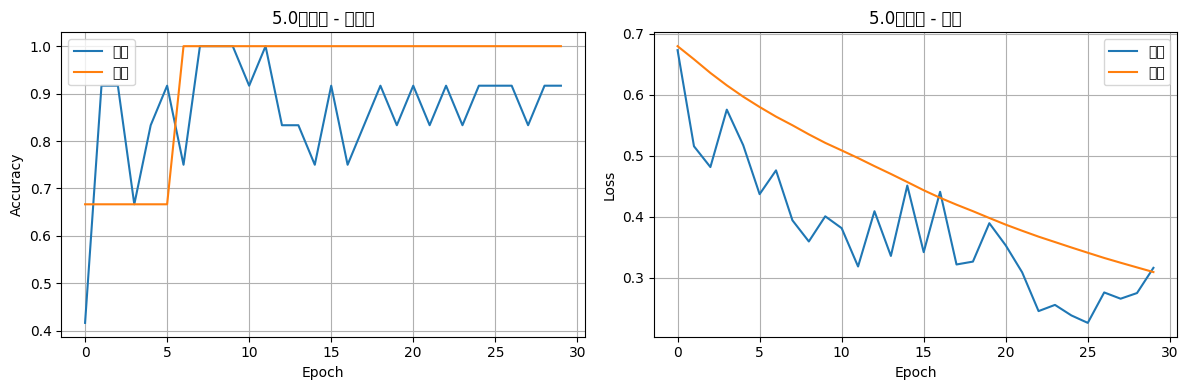

   💾 模型已保存: snore_model_5s.keras

实验2：2秒窗口（无重叠）
  🔍 处理: snoring-1.mp3
    标签统计: 正常3个, 严重0个
    ✅ 生成 3 个片段 (正常:3, 严重:0)
  🔍 处理: snoring-6.mp3
    标签统计: 正常12个, 严重0个
    ✅ 生成 13 个片段 (正常:13, 严重:0)
  🔍 处理: snoring-3.mp3
    标签统计: 正常3个, 严重0个
    ✅ 生成 3 个片段 (正常:3, 严重:0)
  🔍 处理: snoring-4.mp3
    标签统计: 正常6个, 严重0个
    ✅ 生成 8 个片段 (正常:8, 严重:0)
  🔍 处理: snoring-5.mp3
    标签统计: 正常3个, 严重4个
    ✅ 生成 14 个片段 (正常:5, 严重:9)

🧠 训练 2.0秒窗口模型...
   数据形状: X(41, 23), y(41,)
   类别分布: 正常32个, 严重9个
   训练集: 32个 (正常:25, 严重:7)
   测试集: 9个 (正常:7, 严重:2)
Epoch 1/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 171ms/step - accuracy: 0.7600 - loss: 0.5836 - val_accuracy: 0.4286 - val_loss: 0.6181
Epoch 2/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.6000 - loss: 0.6548 - val_accuracy: 0.4286 - val_loss: 0.5853
Epoch 3/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.7200 - loss: 0.5619 - val_accuracy: 0.5714 - val_loss: 0.5552
Epoch 4/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.6400 - loss: 0.5784 - val_accuracy: 0.

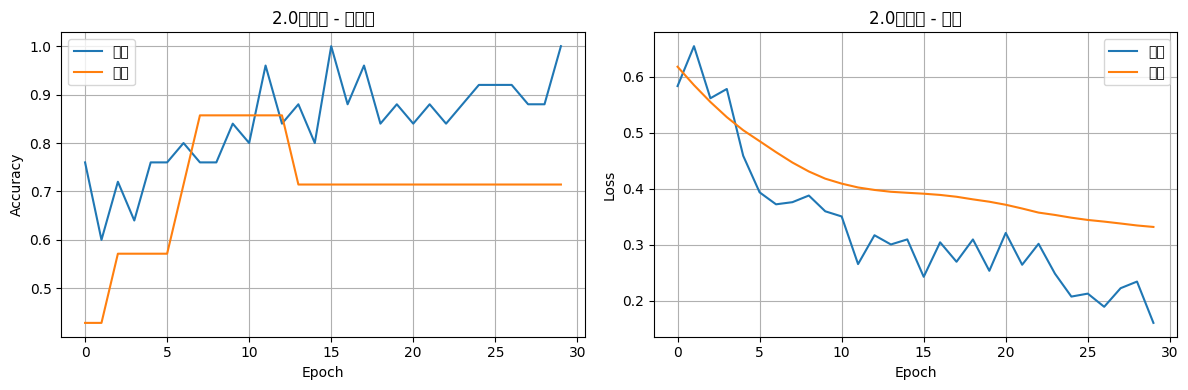

   💾 模型已保存: snore_model_2s.keras

实验3：2秒窗口（50%重叠）
  🔍 处理: snoring-1.mp3
    标签统计: 正常3个, 严重0个
    ✅ 生成 6 个片段 (正常:6, 严重:0)
  🔍 处理: snoring-6.mp3
    标签统计: 正常12个, 严重0个
    ✅ 生成 23 个片段 (正常:23, 严重:0)
  🔍 处理: snoring-3.mp3
    标签统计: 正常3个, 严重0个
    ✅ 生成 6 个片段 (正常:6, 严重:0)
  🔍 处理: snoring-4.mp3
    标签统计: 正常6个, 严重0个
    ✅ 生成 16 个片段 (正常:16, 严重:0)
  🔍 处理: snoring-5.mp3
    标签统计: 正常3个, 严重4个
    ✅ 生成 29 个片段 (正常:10, 严重:19)

🧠 训练 2.0秒窗口模型...
   数据形状: X(80, 23), y(80,)
   类别分布: 正常61个, 严重19个
   训练集: 64个 (正常:49, 严重:15)
   测试集: 16个 (正常:12, 严重:4)
Epoch 1/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.5882 - loss: 0.6927 - val_accuracy: 0.9231 - val_loss: 0.4724
Epoch 2/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.6275 - loss: 0.5814 - val_accuracy: 0.9231 - val_loss: 0.4119
Epoch 3/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8039 - loss: 0.5100 - val_accuracy: 0.9231 - val_loss: 0.3725
Epoch 4/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7843 - loss: 0.4392 - val_acc

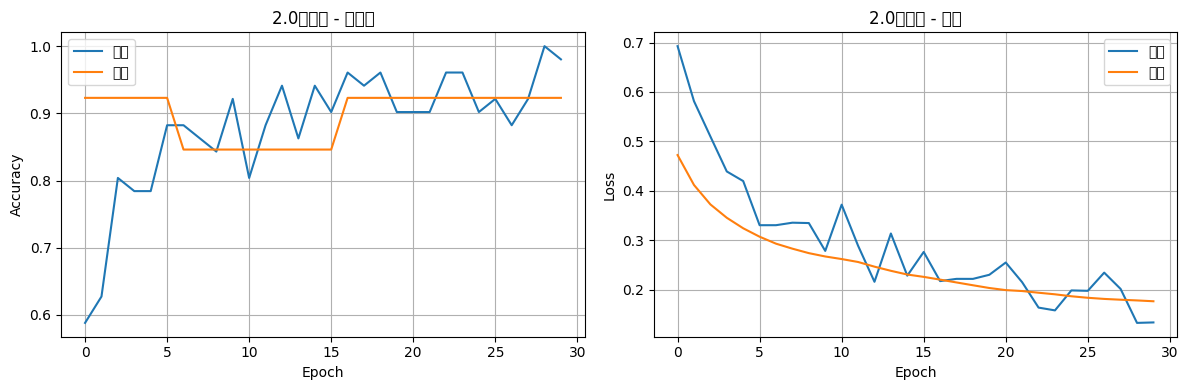

   💾 模型已保存: snore_model_2s.keras

📊 窗口大小对比总结
窗口配置		总样本	正常鼾声	严重鼾声
--------------------------------------------------
5秒窗口	19	16		3
2秒窗口(无重叠)	41	32		9
2秒窗口(50%重叠)	80	61		19

💡 分析建议:
1. 如果2秒窗口效果更好，说明较短窗口更适合捕捉鼾声特征
2. 如果重叠窗口样本更多，说明可以提高时间分辨率
3. 如果类别严重不平衡，建议:
   - 收集更多严重鼾声样本
   - 使用数据增强技术
   - 调整标签阈值

🎉 窗口对比实验完成！


In [3]:
# ============================================================
# 【修复+窗口对比版】鼾声识别
# ============================================================

import librosa
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import joblib
import os
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# ---------------------------------------------------------
# 1. 读取标签函数
# ---------------------------------------------------------
def read_numeric_labels(label_file_path):
    """读取Audacity导出的标签文件，只读取1和2，自动转为0和1"""
    annotations = []
    label_stats = {'1': 0, '2': 0, 'other': 0}
    
    try:
        with open(label_file_path, 'r', encoding='utf-8') as f:
            for line_num, line in enumerate(f, 1):
                line = line.strip()
                if not line:
                    continue
                    
                parts = line.split('\t')
                if len(parts) < 3:
                    continue
                
                try:
                    start_time = float(parts[0])
                    end_time = float(parts[1])
                    label_str = parts[2].strip()
                    
                    if label_str == '1':
                        annotations.append((start_time, end_time, 0))
                        label_stats['1'] += 1
                    elif label_str == '2':
                        annotations.append((start_time, end_time, 1))
                        label_stats['2'] += 1
                    else:
                        label_stats['other'] += 1
                        
                except ValueError:
                    continue
                    
    except FileNotFoundError:
        print(f"❌ 找不到文件: {label_file_path}")
        return [], label_stats
    
    return annotations, label_stats

# ---------------------------------------------------------
# 2. 特征提取
# ---------------------------------------------------------
def extract_enhanced_features(audio_segment, sr):
    """提取音频特征，返回特征数组"""
    features = []
    
    # 1. 时域特征
    rms = librosa.feature.rms(y=audio_segment)[0]
    features.extend([np.mean(rms), np.std(rms), np.max(rms)])
    
    # 2. 过零率
    zcr = librosa.feature.zero_crossing_rate(audio_segment)[0]
    features.extend([np.mean(zcr), np.std(zcr)])
    
    # 3. 频谱质心
    spectral_centroid = librosa.feature.spectral_centroid(y=audio_segment, sr=sr)[0]
    features.extend([np.mean(spectral_centroid), np.std(spectral_centroid)])
    
    # 4. 频谱带宽
    spectral_bandwidth = librosa.feature.spectral_bandwidth(y=audio_segment, sr=sr)[0]
    features.extend([np.mean(spectral_bandwidth), np.std(spectral_bandwidth)])
    
    # 5. MFCC特征（13个系数）
    mfcc = librosa.feature.mfcc(y=audio_segment, sr=sr, n_mfcc=13)
    for i in range(13):
        features.append(np.mean(mfcc[i]))
    
    # 6. 频谱衰减点
    spectral_rolloff = librosa.feature.spectral_rolloff(y=audio_segment, sr=sr)[0]
    features.append(np.mean(spectral_rolloff))
    
    return np.array(features)

# ---------------------------------------------------------
# 3. 创建数据集（支持自定义窗口大小）
# ---------------------------------------------------------
def create_dataset_from_audio(audio_path, label_path, segment_length=2.0, overlap=0.0):
    """
    从音频创建数据集
    segment_length: 窗口大小（秒）
    overlap: 重叠比例（0-1）
    """
    print(f"  🔍 处理: {os.path.basename(audio_path)}")
    
    # 读取标签
    annotations, label_stats = read_numeric_labels(label_path)
    if len(annotations) == 0:
        return None, None
    
    print(f"    标签统计: 正常{label_stats['1']}个, 严重{label_stats['2']}个")
    
    # 加载音频
    y_audio, sr = librosa.load(audio_path, sr=None)
    segment_samples = int(segment_length * sr)
    step_samples = int(segment_samples * (1 - overlap))
    
    X_segments = []
    y_segments = []
    
    # 使用滑动窗口
    for start in range(0, len(y_audio) - segment_samples, step_samples):
        end = start + segment_samples
        seg_start_time = start / sr
        seg_end_time = end / sr
        
        # 统计标签时间
        time_0 = 0.0  # 正常鼾声
        time_1 = 0.0  # 严重鼾声
        
        for ann_start, ann_end, label in annotations:
            overlap_start = max(ann_start, seg_start_time)
            overlap_end = min(ann_end, seg_end_time)
            overlap_duration = max(0, overlap_end - overlap_start)
            
            if overlap_duration > 0:
                if label == 0:
                    time_0 += overlap_duration
                else:
                    time_1 += overlap_duration
        
        total_label_time = time_0 + time_1
        
        # 确定标签
        if total_label_time > 0:
            coverage_ratio = total_label_time / segment_length
            
            if coverage_ratio > 0.3:  # 至少30%的覆盖率
                if time_0 >= time_1:
                    label = 0
                    confidence = time_0 / total_label_time
                else:
                    label = 1
                    confidence = time_1 / total_label_time
                
                if confidence > 0.5:  # 至少50%置信度
                    segment = y_audio[start:end]
                    feat = extract_enhanced_features(segment, sr)
                    X_segments.append(feat)
                    y_segments.append(label)
    
    if len(X_segments) == 0:
        return None, None
    
    X = np.array(X_segments)
    y = np.array(y_segments)
    
    class_counts = Counter(y)
    print(f"    ✅ 生成 {len(X)} 个片段 (正常:{class_counts.get(0,0)}, 严重:{class_counts.get(1,0)})")
    
    return X, y

# ---------------------------------------------------------
# 4. 处理多个文件
# ---------------------------------------------------------
def process_multiple_audios(audio_label_pairs, segment_length=2.0, overlap=0.0):
    """合并多个音频文件的数据"""
    all_X, all_y = [], []
    
    for audio_path, label_path in audio_label_pairs:
        if not os.path.exists(audio_path):
            print(f"⚠️  跳过：找不到音频 {audio_path}")
            continue
        if not os.path.exists(label_path):
            print(f"⚠️  跳过：找不到标签 {label_path}")
            continue
            
        X, y = create_dataset_from_audio(audio_path, label_path, segment_length, overlap)
        if X is not None:
            all_X.append(X)
            all_y.append(y)
    
    if not all_X:
        return None, None
    
    X_combined = np.vstack(all_X)
    y_combined = np.concatenate(all_y)
    
    return X_combined, y_combined

# ---------------------------------------------------------
# 5. 修复的训练函数
# ---------------------------------------------------------
def train_model(X_all, y_all, test_size=0.2, segment_length=5.0):
    """
    训练二分类模型 - 修复版
    """
    print(f"\n🧠 训练 {segment_length}秒窗口模型...")
    print(f"   数据形状: X{X_all.shape}, y{y_all.shape}")
    print(f"   类别分布: 正常{np.sum(y_all==0)}个, 严重{np.sum(y_all==1)}个")
    
    # 1. 标准化
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_all)
    
    # 2. 划分数据集
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y_all, 
        test_size=test_size, 
        random_state=42,
        stratify=y_all
    )
    
    print(f"   训练集: {len(y_train)}个 (正常:{np.sum(y_train==0)}, 严重:{np.sum(y_train==1)})")
    print(f"   测试集: {len(y_test)}个 (正常:{np.sum(y_test==0)}, 严重:{np.sum(y_test==1)})")
    
    # 3. 构建更简单的模型（减少过拟合风险）
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(2, activation='softmax')
    ])
    
    # 4. 编译模型
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    # 5. 训练
    history = model.fit(
        X_train, y_train,
        epochs=30,
        batch_size=16,
        validation_split=0.2,
        verbose=1
    )
    
    # 6. 评估
    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    print(f"   ✅ 测试准确率: {acc:.2%}")
    
    # 7. 预测并显示分类报告
    y_pred = model.predict(X_test)
    y_pred_classes = np.argmax(y_pred, axis=1)
    
    from sklearn.metrics import classification_report, confusion_matrix
    print("\n📋 分类报告:")
    print(classification_report(y_test, y_pred_classes, target_names=['正常', '严重']))
    
    print("📈 混淆矩阵:")
    print(confusion_matrix(y_test, y_pred_classes))
    
    # 8. 绘制曲线
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='训练')
    plt.plot(history.history['val_accuracy'], label='验证')
    plt.title(f'{segment_length}秒窗口 - 准确率')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='训练')
    plt.plot(history.history['val_loss'], label='验证')
    plt.title(f'{segment_length}秒窗口 - 损失')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()
    
    # 9. 保存模型
    model_filename = f'snore_model_{int(segment_length)}s.keras'
    scaler_filename = f'scaler_{int(segment_length)}s.pkl'
    
    model.save(model_filename)
    joblib.dump(scaler, scaler_filename)
    print(f"   💾 模型已保存: {model_filename}")
    
    return model, scaler, history

# ---------------------------------------------------------
# 主程序：对比不同窗口大小
# ---------------------------------------------------------
if __name__ == "__main__":
    print("⚙️ 配置文件中...")
    
    # 文件路径
    audio_label_pairs = [
        ('./my_mp3_snores/snoring-1.mp3', './my_mp3_snores/snoringlable-1.txt'),
        ('./my_mp3_snores/snoring-6.mp3', './my_mp3_snores/snoringlable-6.txt'),
        ('./my_mp3_snores/snoring-3.mp3', './my_mp3_snores/snoringlable-3.txt'),
        ('./my_mp3_snores/snoring-4.mp3', './my_mp3_snores/snoringlable-4.txt'),
        ('./my_mp3_snores/snoring-5.mp3', './my_mp3_snores/snoringlable-5.txt'),
    ]
    
    print(f"配置了 {len(audio_label_pairs)} 个文件\n")
    
    # 实验1：5秒窗口（无重叠）
    print("="*70)
    print("实验1：5秒窗口（无重叠）")
    print("="*70)
    X_5s, y_5s = process_multiple_audios(
        audio_label_pairs, 
        segment_length=5.0, 
        overlap=0.0
    )
    
    if X_5s is not None and len(X_5s) > 0:
        model_5s, scaler_5s, history_5s = train_model(X_5s, y_5s, segment_length=5.0)
    else:
        print("❌ 5秒窗口数据处理失败")
    
    print("\n" + "="*70)
    
    # 实验2：2秒窗口（无重叠）
    print("实验2：2秒窗口（无重叠）")
    print("="*70)
    X_2s, y_2s = process_multiple_audios(
        audio_label_pairs, 
        segment_length=2.0, 
        overlap=0.0
    )
    
    if X_2s is not None and len(X_2s) > 0:
        model_2s, scaler_2s, history_2s = train_model(X_2s, y_2s, segment_length=2.0)
    else:
        print("❌ 2秒窗口数据处理失败")
    
    print("\n" + "="*70)
    
    # 实验3：2秒窗口（50%重叠）
    print("实验3：2秒窗口（50%重叠）")
    print("="*70)
    X_2s_overlap, y_2s_overlap = process_multiple_audios(
        audio_label_pairs, 
        segment_length=2.0, 
        overlap=0.5
    )
    
    if X_2s_overlap is not None and len(X_2s_overlap) > 0:
        model_2s_ov, scaler_2s_ov, history_2s_ov = train_model(X_2s_overlap, y_2s_overlap, segment_length=2.0)
    else:
        print("❌ 2秒窗口（重叠）数据处理失败")
    
    # 对比结果汇总
    print("\n" + "="*70)
    print("📊 窗口大小对比总结")
    print("="*70)
    
    results = []
    
    if X_5s is not None:
        results.append(("5秒窗口", len(y_5s), np.sum(y_5s==0), np.sum(y_5s==1)))
    
    if X_2s is not None:
        results.append(("2秒窗口(无重叠)", len(y_2s), np.sum(y_2s==0), np.sum(y_2s==1)))
    
    if X_2s_overlap is not None:
        results.append(("2秒窗口(50%重叠)", len(y_2s_overlap), np.sum(y_2s_overlap==0), np.sum(y_2s_overlap==1)))
    
    print("窗口配置\t\t总样本\t正常鼾声\t严重鼾声")
    print("-"*50)
    for name, total, normal, severe in results:
        print(f"{name}\t{total}\t{normal}\t\t{severe}")
    
    print("\n💡 分析建议:")
    print("1. 如果2秒窗口效果更好，说明较短窗口更适合捕捉鼾声特征")
    print("2. 如果重叠窗口样本更多，说明可以提高时间分辨率")
    print("3. 如果类别严重不平衡，建议:")
    print("   - 收集更多严重鼾声样本")
    print("   - 使用数据增强技术")
    print("   - 调整标签阈值")
    
    print("\n🎉 窗口对比实验完成！")

🔧 鼾声识别系统 - 新音频识别模块
📂 加载模型: snore_model_2s.keras
📂 加载标准化器: scaler_2s.pkl
🎵 处理新音频: snoring-6.mp3
   窗口长度: 2.0秒, 重叠: 0.0%
   音频信息: 采样率=44100Hz, 时长=42.4秒
   切分为 21 个片段
🔍 提取特征中...
   成功提取 21 个片段的特征
🤖 模型预测中...


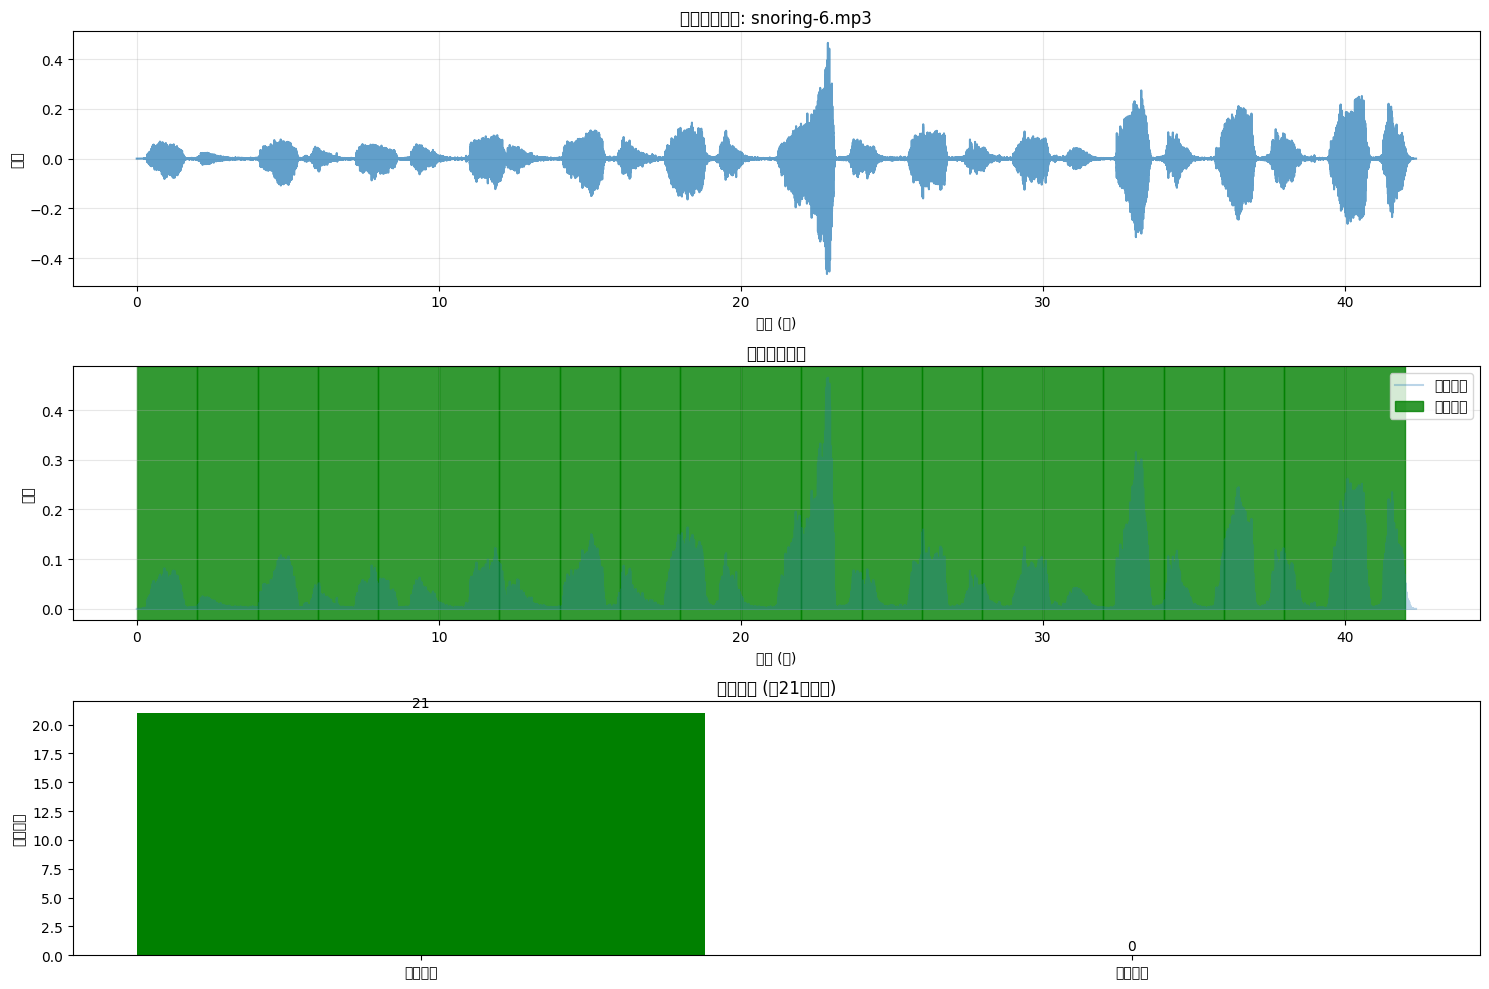


📊 识别结果汇总:
音频文件: snoring-6.mp3
总片段数: 21
正常鼾声: 21个 (100.0%)
严重鼾声: 0个 (0.0%)
平均置信度: 99.53%
💾 预测结果已保存到: prediction_results.txt

✅ 分析结果：未检测到严重鼾声
   建议：继续保持良好的睡眠习惯

🎉 识别完成！


In [22]:
# ============================================================
# 【修复版】鼾声识别系统 - 新音频识别模块（修复UnboundLocalError）
# ============================================================

import librosa
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
import joblib
import os
import matplotlib.pyplot as plt
import warnings
import datetime
warnings.filterwarnings('ignore')

# ---------------------------------------------------------
# 1. 加载训练好的模型和标准化器
# ---------------------------------------------------------
def load_model_and_scaler(model_path, scaler_path):
    """
    加载之前训练保存的模型和标准化器
    """
    print(f"📂 加载模型: {model_path}")
    model = tf.keras.models.load_model(model_path)
    
    print(f"📂 加载标准化器: {scaler_path}")
    scaler = joblib.load(scaler_path)
    
    return model, scaler

# ---------------------------------------------------------
# 2. 特征提取函数（与训练时完全一致）
# ---------------------------------------------------------
def extract_enhanced_features(audio_segment, sr):
    """提取音频特征，返回特征数组（必须与训练时完全一致）"""
    features = []
    
    # 1. 时域特征
    rms = librosa.feature.rms(y=audio_segment)[0]
    features.extend([np.mean(rms), np.std(rms), np.max(rms)])
    
    # 2. 过零率
    zcr = librosa.feature.zero_crossing_rate(audio_segment)[0]
    features.extend([np.mean(zcr), np.std(zcr)])
    
    # 3. 频谱质心
    spectral_centroid = librosa.feature.spectral_centroid(y=audio_segment, sr=sr)[0]
    features.extend([np.mean(spectral_centroid), np.std(spectral_centroid)])
    
    # 4. 频谱带宽
    spectral_bandwidth = librosa.feature.spectral_bandwidth(y=audio_segment, sr=sr)[0]
    features.extend([np.mean(spectral_bandwidth), np.std(spectral_bandwidth)])
    
    # 5. MFCC特征（13个系数）
    mfcc = librosa.feature.mfcc(y=audio_segment, sr=sr, n_mfcc=13)
    for i in range(13):
        features.append(np.mean(mfcc[i]))
    
    # 6. 频谱衰减点
    spectral_rolloff = librosa.feature.spectral_rolloff(y=audio_segment, sr=sr)[0]
    features.append(np.mean(spectral_rolloff))
    
    return np.array(features)

# ---------------------------------------------------------
# 3. 处理新音频文件
# ---------------------------------------------------------
def process_new_audio(audio_path, segment_length=5.0, overlap=0.0):
    """
    处理新的未标记音频文件
    segment_length: 窗口长度，必须与训练时一致
    overlap: 重叠比例，必须与训练时一致
    """
    print(f"🎵 处理新音频: {os.path.basename(audio_path)}")
    print(f"   窗口长度: {segment_length}秒, 重叠: {overlap*100}%")
    
    # 加载音频
    y_audio, sr = librosa.load(audio_path, sr=None)
    print(f"   音频信息: 采样率={sr}Hz, 时长={len(y_audio)/sr:.1f}秒")
    
    # 计算切分参数
    segment_samples = int(segment_length * sr)
    step_samples = int(segment_samples * (1 - overlap))
    
    segments = []
    segment_times = []
    
    # 按窗口切分音频
    for start in range(0, len(y_audio) - segment_samples, step_samples):
        end = start + segment_samples
        seg_start_time = start / sr
        seg_end_time = end / sr
        
        # 提取音频段
        segment = y_audio[start:end]
        segments.append(segment)
        segment_times.append((seg_start_time, seg_end_time))
    
    print(f"   切分为 {len(segments)} 个片段")
    return y_audio, sr, segments, segment_times

# ---------------------------------------------------------
# 4. 提取特征并进行预测
# ---------------------------------------------------------
def predict_audio(audio_path, model, scaler, segment_length=5.0, overlap=0.0):
    """
    对新音频进行预测
    """
    # 处理音频
    y_audio, sr, segments, segment_times = process_new_audio(
        audio_path, segment_length, overlap
    )
    
    if len(segments) == 0:
        print("❌ 音频太短，无法切分")
        return None, None, None, None, None
    
    # 提取特征
    print("🔍 提取特征中...")
    all_features = []
    valid_segments = []
    valid_times = []
    
    for i, (segment, (start_time, end_time)) in enumerate(zip(segments, segment_times)):
        try:
            features = extract_enhanced_features(segment, sr)
            if len(features) == 23:  # 确保特征维度正确
                all_features.append(features)
                valid_segments.append(segment)
                valid_times.append((start_time, end_time))
        except Exception as e:
            print(f"   跳过片段 {i}: {e}")
            continue
    
    if len(all_features) == 0:
        print("❌ 无法提取特征")
        return None, None, None, None, None
    
    X_new = np.array(all_features)
    print(f"   成功提取 {len(X_new)} 个片段的特征")
    
    # 标准化（使用训练时的scaler）
    X_scaled = scaler.transform(X_new)
    
    # 预测
    print("🤖 模型预测中...")
    predictions = model.predict(X_scaled, verbose=0)
    
    # 转换为类别（0=正常，1=严重）
    y_pred_classes = np.argmax(predictions, axis=1)
    y_pred_probs = np.max(predictions, axis=1)  # 置信度
    
    return y_pred_classes, y_pred_probs, valid_times, y_audio, sr

# ---------------------------------------------------------
# 5. 可视化预测结果（已修复）
# ---------------------------------------------------------
def visualize_predictions(y_audio, sr, predictions, times, probs, audio_name):
    """
    可视化预测结果 - 修复版
    """
    fig, axes = plt.subplots(3, 1, figsize=(15, 10))
    
    # 1. 原始波形
    time_axis = np.arange(len(y_audio)) / sr
    axes[0].plot(time_axis, y_audio, alpha=0.7)
    axes[0].set_title(f'原始音频波形: {audio_name}')
    axes[0].set_xlabel('时间 (秒)')
    axes[0].set_ylabel('振幅')
    axes[0].grid(True, alpha=0.3)
    
    # 2. 预测结果时间线
    axes[1].plot(time_axis, np.abs(y_audio), alpha=0.3, label='音频包络')
    
    # 添加图例标签控制（修复了i变量问题）
    normal_label_added = False
    severe_label_added = False
    
    # 为每个片段着色
    for idx, ((start, end), pred, prob) in enumerate(zip(times, predictions, probs)):
        color = 'green' if pred == 0 else 'red'
        alpha = min(0.3 + prob * 0.5, 0.8)  # 置信度越高颜色越深
        
        # 控制图例标签只显示一次
        if pred == 0 and not normal_label_added:
            label = '正常鼾声'
            normal_label_added = True
        elif pred == 1 and not severe_label_added:
            label = '严重鼾声'
            severe_label_added = True
        else:
            label = ""
        
        axes[1].axvspan(start, end, color=color, alpha=alpha, label=label)
    
    axes[1].set_title('鼾声识别结果')
    axes[1].set_xlabel('时间 (秒)')
    axes[1].set_ylabel('振幅')
    axes[1].legend(loc='upper right')
    axes[1].grid(True, alpha=0.3)
    
    # 3. 统计信息
    normal_count = np.sum(predictions == 0)
    severe_count = np.sum(predictions == 1)
    total_count = len(predictions)
    
    axes[2].bar(['正常鼾声', '严重鼾声'], [normal_count, severe_count], 
               color=['green', 'red'])
    axes[2].set_title(f'识别统计 (共{total_count}个片段)')
    axes[2].set_ylabel('片段数量')
    
    # 在柱状图上显示数字
    for i, count in enumerate([normal_count, severe_count]):
        axes[2].text(i, count + 0.5, str(count), ha='center')
    
    plt.tight_layout()
    plt.show()
    
    # 打印详细结果
    print("\n" + "="*60)
    print("📊 识别结果汇总:")
    print("="*60)
    print(f"音频文件: {audio_name}")
    print(f"总片段数: {total_count}")
    print(f"正常鼾声: {normal_count}个 ({normal_count/total_count:.1%})")
    print(f"严重鼾声: {severe_count}个 ({severe_count/total_count:.1%})")
    print(f"平均置信度: {np.mean(probs):.2%}")
    
    # 列出严重鼾声的时间段
    if severe_count > 0:
        print("\n⚠️  严重鼾声时间段:")
        for i, ((start, end), pred, prob) in enumerate(zip(times, predictions, probs)):
            if pred == 1:
                print(f"  {i+1:2d}. {start:5.1f}-{end:5.1f}秒 (置信度: {prob:.1%})")

# ---------------------------------------------------------
# 6. 保存预测结果
# ---------------------------------------------------------
def save_predictions(audio_name, predictions, times, probs, output_file="prediction_results.txt"):
    """
    将预测结果保存到文件
    """
    with open(output_file, 'w', encoding='utf-8') as f:
        f.write(f"音频文件: {audio_name}\n")
        f.write(f"预测时间: {datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
        f.write("="*50 + "\n")
        
        normal_count = np.sum(predictions == 0)
        severe_count = np.sum(predictions == 1)
        
        f.write(f"总片段数: {len(predictions)}\n")
        f.write(f"正常鼾声: {normal_count}个\n")
        f.write(f"严重鼾声: {severe_count}个\n")
        f.write("="*50 + "\n\n")
        
        f.write("详细时间段:\n")
        f.write("序号 | 开始时间 | 结束时间 | 类型 | 置信度\n")
        f.write("-"*50 + "\n")
        
        for i, ((start, end), pred, prob) in enumerate(zip(times, predictions, probs)):
            pred_type = "正常" if pred == 0 else "严重"
            f.write(f"{i+1:4d} | {start:7.1f} | {end:7.1f} | {pred_type:4s} | {prob:.1%}\n")
    
    print(f"💾 预测结果已保存到: {output_file}")

# ---------------------------------------------------------
# 主程序：识别新音频
# ---------------------------------------------------------
if __name__ == "__main__":
    print("🔧 鼾声识别系统 - 新音频识别模块")
    print("="*60)
    
    # ============================================
    # 第1步：选择要使用的模型
    # ============================================
    # 注意：这里的模型文件必须与窗口设置匹配！
    
    # 选项1：5秒窗口模型（无重叠）
    # model_path = "snore_model_5s.keras"
    # scaler_path = "scaler_5s.pkl"
    # segment_length = 5.0
    # overlap = 0.0
    
    # 选项2：2秒窗口模型（无重叠）
    model_path = "snore_model_2s.keras"
    scaler_path = "scaler_2s.pkl"
    segment_length = 2.0
    overlap = 0.0
    
    # 选项3：2秒窗口模型（50%重叠）
    # model_path = "snore_model_2s.keras"  # 注意：需要对应的模型文件
    # scaler_path = "scaler_2s.pkl"
    # segment_length = 2.0
    # overlap = 0.5
    
    # ============================================
    # 第2步：加载模型
    # ============================================
    model, scaler = load_model_and_scaler(model_path, scaler_path)
    
    # ============================================
    # 第3步：要识别的新音频文件
    # ============================================
    # 替换为你的新音频文件路径
    new_audio_path = "./my_mp3_snores/snoring-6.mp3"  # 修改这里！
    
    if not os.path.exists(new_audio_path):
        print(f"❌ 找不到音频文件: {new_audio_path}")
        print("请确保:")
        print("1. 文件路径正确")
        print("2. 文件扩展名正确 (.mp3, .wav等)")
        print("3. 文件确实存在")
    else:
        # ============================================
        # 第4步：进行预测
        # ============================================
        predictions, probs, times, y_audio, sr = predict_audio(
            new_audio_path, model, scaler, segment_length, overlap
        )
        
        if predictions is not None:
            # ============================================
            # 第5步：可视化结果
            # ============================================
            audio_name = os.path.basename(new_audio_path)
            visualize_predictions(y_audio, sr, predictions, times, probs, audio_name)
            
            # ============================================
            # 第6步：保存结果
            # ============================================
            save_predictions(audio_name, predictions, times, probs)
            
            # ============================================
            # 第7步：给出建议
            # ============================================
            severe_count = np.sum(predictions == 1)
            total_count = len(predictions)
            
            if severe_count == 0:
                print("\n✅ 分析结果：未检测到严重鼾声")
                print("   建议：继续保持良好的睡眠习惯")
            elif severe_count / total_count < 0.1:
                print("\n⚠️  分析结果：检测到少量严重鼾声")
                print("   建议：关注睡眠质量，定期检查")
            elif severe_count / total_count < 0.3:
                print("\n⚠️  分析结果：检测到中度严重鼾声")
                print("   建议：考虑进行睡眠呼吸监测")
            else:
                print("\n🚨 分析结果：检测到大量严重鼾声")
                print("   建议：尽快咨询专业医生")
            
            print("\n🎉 识别完成！")